# 06: RR Lyrae Color Excess and Gaia $G$-band Extinction

This notebook reuses the class-specific Gaia period-color summaries from `05.ipynb` and applies them to the shared RRab/RRc Gaia full-catalog cache. The goal is to estimate the intrinsic color for each cached RRab and RRc star, derive the color excess $E(G_{\mathrm{BP}}-G_{\mathrm{RP}})$, convert it to an empirical $A_G$ using $R_G = 2.0$, and compare that empirical extinction to Gaia DR3 `g_absorption`.


In [1]:
from pathlib import Path

import numpy as np
from astropy import table

from ugdatalab import (
    build_reddening_quality_mask,
    compute_period_color_extinction,
    empirical_vs_catalog_extinction,
    load_optical_pc_comparison_data,
    load_table_npz,
    plot_empirical_vs_catalog_extinction_comparison,
    rrlyrae_class_mask,
    save_table_npz,
)

PC_COMPARISON_PATH = Path("rrlyrae_optical_pc_comparison_data.npz")
FULL_CATALOG_PATH = Path("rrlyrae_rrab_rrc_full_catalog.npz")
EXTINCTION_CATALOG_PATH = Path("rrlyrae_extinction_catalog.npz")
R_G = 2.0

## Load the Shared RRab/RRc Catalog and Saved Period-Color Fits

`05.ipynb` uses two notebook-local `.npz` files in `labs/01/`:

- `rrlyrae_rrab_rrc_full_catalog.npz` with the shared RRab/RRc Gaia full-catalog cache.
- `rrlyrae_optical_pc_comparison_data.npz` with the summarized RRab and RRc period-color fit values.

Loading these local artifacts avoids the slow Gaia-query path entirely.


In [2]:
try:
    pc_comparison = load_optical_pc_comparison_data(PC_COMPARISON_PATH)
    rrlyrae_full = load_table_npz(FULL_CATALOG_PATH)
except FileNotFoundError as exc:
    raise RuntimeError(
        'Required local .npz handoff files were not available in labs/01. '
        'Run 05.ipynb to regenerate them before executing this notebook.'
    ) from exc

pc_summaries = {
    rr_class: {
        'slope_median': comparison.slope_median,
        'slope_std': comparison.slope_std,
        'intercept_median': comparison.intercept_median,
        'intercept_std': comparison.intercept_std,
        'intrinsic_sigma_median': comparison.intrinsic_sigma_median,
        'intrinsic_sigma_std': comparison.intrinsic_sigma_std,
    }
    for rr_class, comparison in pc_comparison.items()
}

class_counts = {
    'RRab': int(rrlyrae_class_mask(rrlyrae_full, 'RRab').sum()),
    'RRc': int(rrlyrae_class_mask(rrlyrae_full, 'RRc').sum()),
}

print(f"Shared RRab/RRc catalog: {len(rrlyrae_full):,} stars")
for rr_class, count in class_counts.items():
    print(f"  {rr_class}: {count:,}")

posterior_summary_table = table.Table(
    rows=[
        {
            'class': rr_class,
            'n_fit': int(len(comparison.x_obs)),
            'slope_median': round(comparison.slope_median, 4),
            'slope_std': round(comparison.slope_std, 4),
            'intercept_median': round(comparison.intercept_median, 4),
            'intercept_std': round(comparison.intercept_std, 4),
            'sigma_c_median': round(comparison.intrinsic_sigma_median, 4),
        }
        for rr_class, comparison in pc_comparison.items()
    ]
)
posterior_summary_table


Shared RRab/RRc catalog: 269,772 stars
  RRab: 175,350
  RRc: 94,422


class,n_fit,slope_median,slope_std,intercept_median,intercept_std,sigma_c_median
str4,int64,float64,float64,float64,float64,float64
RRab,560,0.2483,0.0417,0.7095,0.0103,0.0502
RRc,317,0.4788,0.0536,0.6817,0.0267,0.0511


In [3]:
extinction_scope_table = table.Table(
    rows=[
        {
            "artifact": "rrlyrae_rrab_rrc_full_catalog.npz",
            "classes_present": "RRab, RRc",
            "rows": int(len(rrlyrae_full)),
            "empirical_A_G_defined": "Yes",
            "note": "These are the subclasses with calibrated intrinsic-color relations from 05.ipynb.",
        },
        {
            "artifact": "Full Gaia RR Lyrae catalog outside this cache",
            "classes_present": "RRd and other classes not loaded here",
            "rows": "not carried into 06.ipynb",
            "empirical_A_G_defined": "No",
            "note": "The lab does not derive an intrinsic-color calibration for those classes.",
        },
    ]
)
extinction_scope_table

artifact,classes_present,rows,empirical_A_G_defined,note
str45,str37,str25,str3,str81
rrlyrae_rrab_rrc_full_catalog.npz,"RRab, RRc",269772,Yes,These are the subclasses with calibrated intrinsic-color relations from 05.ipynb.
Full Gaia RR Lyrae catalog outside this cache,RRd and other classes not loaded here,not carried into 06.ipynb,No,The lab does not derive an intrinsic-color calibration for those classes.


## Compute $E(G_{\mathrm{BP}}-G_{\mathrm{RP}})$ and $A_G$

For each RRab or RRc star we evaluate the class-specific intrinsic color relation from `05.ipynb`, then compute

$$
E(G_{\mathrm{BP}}-G_{\mathrm{RP}}) = (G_{\mathrm{BP}}-G_{\mathrm{RP}})_{\mathrm{obs}} - (G_{\mathrm{BP}}-G_{\mathrm{RP}})_{\mathrm{int}},
$$

and convert it to empirical extinction with

$$
A_G^{\mathrm{calc}} = R_G\,E(G_{\mathrm{BP}}-G_{\mathrm{RP}}), \qquad R_G = 2.0.
$$

**On the choice $R_G = 2.0$:** The ratio $R_G = A_G / E(G_{\mathrm{BP}} - G_{\mathrm{RP}})$ depends on the extinction law and the effective stellar temperature. The value $R_G = 2.0$ is adopted following Wang & Chen (2019, ApJ, 877, 116), who empirically calibrate the optical-to-mid-infrared extinction law using APOGEE, Gaia, WISE, and 2MASS photometry and find $R_G \approx 2.0$ for typical giant and sub-giant temperatures. This is consistent with applying the Cardelli, Clayton & Mathis (1989, ApJ, 345, 245) extinction law as updated by O'Donnell (1994, ApJ, 422, 158) to the Gaia $G$ bandpass with $R_V = 3.1$. For RR Lyrae temperatures ($T_{\rm eff} \sim 6000$–7500 K), $R_G \approx 2.0$ is an appropriate approximation, though it carries a mild color dependence of order $\pm 0.1$ across the temperature range of the instability strip.

The helper below also propagates observational BP/RP color noise, posterior coefficient uncertainty, and the fitted intrinsic color scatter into `sigma_E`. The shared full-catalog cache used here already excludes RRd, so this notebook is intentionally restricted to RRab and RRc.

In [4]:
rrlyrae_extinction = compute_period_color_extinction(
    rrlyrae_full,
    pc_summaries,
    r_g=R_G,
    copy=True,
)

valid_empirical = np.isfinite(np.asarray(rrlyrae_extinction['E_bprp'], dtype=float))
valid_by_class = table.Table(
    rows=[
        {
            'class': rr_class,
            'valid_empirical_rows': int((valid_empirical & rrlyrae_class_mask(rrlyrae_extinction, rr_class)).sum()),
        }
        for rr_class in ('RRab', 'RRc')
    ]
)
valid_by_class


class,valid_empirical_rows
str4,int64
RRab,168113
RRc,86056


In [5]:
save_table_npz(EXTINCTION_CATALOG_PATH, rrlyrae_extinction)
{"saved": str(EXTINCTION_CATALOG_PATH.resolve()), "rows": len(rrlyrae_extinction)}

{'saved': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_extinction_catalog.npz',
 'rows': 269772}

## Compare to Gaia DR3 `g_absorption`

The Gaia DR3 RR Lyrae processing pipeline publishes `g_absorption` as a catalog extinction estimate. Our empirical $A_G$ is built from the observed color minus a class-specific intrinsic color relation, so the two quantities should be correlated but need not match star-by-star. The comparison is therefore a consistency check rather than an identity test.

Before comparing the two, I first remove catalog values that are unphysical for an optical RR Lyrae sample: negative extinctions and entries with $g_{\mathrm{absorption}} > G + 1$. The upper bound is intentionally conservative. It assumes an RR Lyrae could be as bright as $M_G \approx -1$ and still have non-negative distance modulus, so any row violating that inequality cannot represent a physically plausible $G$-band extinction.

I then apply `build_reddening_quality_mask(...)` to reject low-S/N or BP/RP-excess-contaminated photometry before interpreting residual scatter. In the current cached RRab/RRc artifact, Gaia DR3 `g_absorption` is finite only for RRab sources, so the final catalog comparison below is effectively RRab-only even though empirical extinction quantities are still computed for both RRab and RRc.


In [6]:
from IPython.display import display

empirical = np.asarray(rrlyrae_extinction['A_G_calc'], dtype=float)
catalog = np.asarray(rrlyrae_extinction['g_absorption'], dtype=float)
phot_g = np.asarray(rrlyrae_extinction['phot_g_mean_mag'], dtype=float)

empirical_finite_mask = np.isfinite(empirical)
catalog_negative_mask = np.isfinite(catalog) & (catalog < 0.0)
catalog_too_large_mask = np.isfinite(catalog) & np.isfinite(phot_g) & (catalog > phot_g + 1.0)
catalog_outlier_mask = catalog_negative_mask | catalog_too_large_mask
catalog_physical_mask = np.isfinite(catalog) & ~catalog_outlier_mask
reddening_quality_mask = build_reddening_quality_mask(rrlyrae_extinction)
comparison_mask = empirical_finite_mask & catalog_physical_mask & reddening_quality_mask

catalog_outlier_reason = np.full(len(rrlyrae_extinction), '', dtype='U20')
catalog_outlier_reason[catalog_negative_mask] = 'negative_A_G'
catalog_outlier_reason[catalog_too_large_mask] = 'A_G_gt_G_plus_1'
rrlyrae_extinction['catalog_ag_is_physical'] = catalog_physical_mask
rrlyrae_extinction['catalog_ag_outlier_reason'] = catalog_outlier_reason
rrlyrae_extinction['reddening_quality_ok'] = reddening_quality_mask
rrlyrae_extinction['extinction_comparison_ok'] = comparison_mask

sample_masks = [
    ('All cached rows', np.ones(len(rrlyrae_extinction), dtype=bool)),
    ('RRab', rrlyrae_class_mask(rrlyrae_extinction, 'RRab')),
    ('RRc', rrlyrae_class_mask(rrlyrae_extinction, 'RRc')),
]

def _stage_summary(label, mask):
    return {
        'sample': label,
        'total_rows': int(mask.sum()),
        'empirical_rows': int((mask & empirical_finite_mask).sum()),
        'finite_catalog_rows': int((mask & np.isfinite(catalog)).sum()),
        'physical_catalog_rows': int((mask & catalog_physical_mask).sum()),
        'quality_rows': int((mask & reddening_quality_mask).sum()),
        'comparison_rows': int((mask & comparison_mask).sum()),
    }

sample_flow_summary = table.Table(
    rows=[_stage_summary(label, mask) for label, mask in sample_masks]
)

def _mask_summary(mask, label):
    values = catalog[mask]
    return {
        'criterion': label,
        'N': int(mask.sum()),
        'min_g_absorption': np.nan if len(values) == 0 else round(float(np.min(values)), 4),
        'max_g_absorption': np.nan if len(values) == 0 else round(float(np.max(values)), 4),
    }

catalog_outlier_summary = table.Table(
    rows=[
        _mask_summary(catalog_negative_mask, 'g_absorption < 0'),
        _mask_summary(catalog_too_large_mask, 'g_absorption > G + 1'),
    ]
)

catalog_outliers = rrlyrae_extinction[catalog_outlier_mask][
    'source_id',
    'best_classification',
    'phot_g_mean_mag',
    'g_absorption',
    'g_absorption_error',
    'bp_rp',
    'l',
    'b',
    'catalog_ag_outlier_reason',
].copy()
catalog_outliers.sort('g_absorption')

positive_catalog_outliers = catalog_outliers[
    catalog_outliers['catalog_ag_outlier_reason'] == 'A_G_gt_G_plus_1'
]

positive_catalog_outliers = positive_catalog_outliers[
    'source_id',
    'best_classification',
    'phot_g_mean_mag',
    'g_absorption',
    'g_absorption_error',
    'bp_rp',
    'l',
    'b',
].copy()

comparison = empirical_vs_catalog_extinction(rrlyrae_extinction[comparison_mask])

def _residual_summary(mask, label):
    finite = comparison_mask & mask
    residual = empirical[finite] - catalog[finite]
    if len(residual) == 0:
        return {
            'sample': label,
            'N': 0,
            'median_resid': np.nan,
            'mad_sigma': np.nan,
            'rms_resid': np.nan,
        }
    med = float(np.median(residual))
    mad_sigma = float(1.4826 * np.median(np.abs(residual - med)))
    rms = float(np.sqrt(np.mean(residual**2)))
    return {
        'sample': label,
        'N': int(finite.sum()),
        'median_resid': round(med, 4),
        'mad_sigma': round(mad_sigma, 4),
        'rms_resid': round(rms, 4),
    }

comparison_summary = table.Table(
    rows=[
        _residual_summary(np.ones(len(rrlyrae_extinction), dtype=bool), 'Quality-filtered matches'),
        _residual_summary(rrlyrae_class_mask(rrlyrae_extinction, 'RRab'), 'RRab'),
        _residual_summary(rrlyrae_class_mask(rrlyrae_extinction, 'RRc'), 'RRc'),
    ]
)

display(sample_flow_summary)
display(catalog_outlier_summary)
comparison_summary


sample,total_rows,empirical_rows,finite_catalog_rows,physical_catalog_rows,quality_rows,comparison_rows
str15,int64,int64,int64,int64,int64,int64
All cached rows,269772,254169,142867,133306,177784,109325
RRab,175350,168113,142867,133306,124105,109325
RRc,94422,86056,0,0,53679,0


criterion,N,min_g_absorption,max_g_absorption
str20,int64,float64,float64
g_absorption < 0,9503,-1.2792,-0.0
g_absorption > G + 1,58,19.1658,3367.3193


sample,N,median_resid,mad_sigma,rms_resid
str24,int64,float64,float64,float64
Quality-filtered matches,109325,-0.114,0.1638,0.369
RRab,109325,-0.114,0.1638,0.369
RRc,0,nan,nan,nan


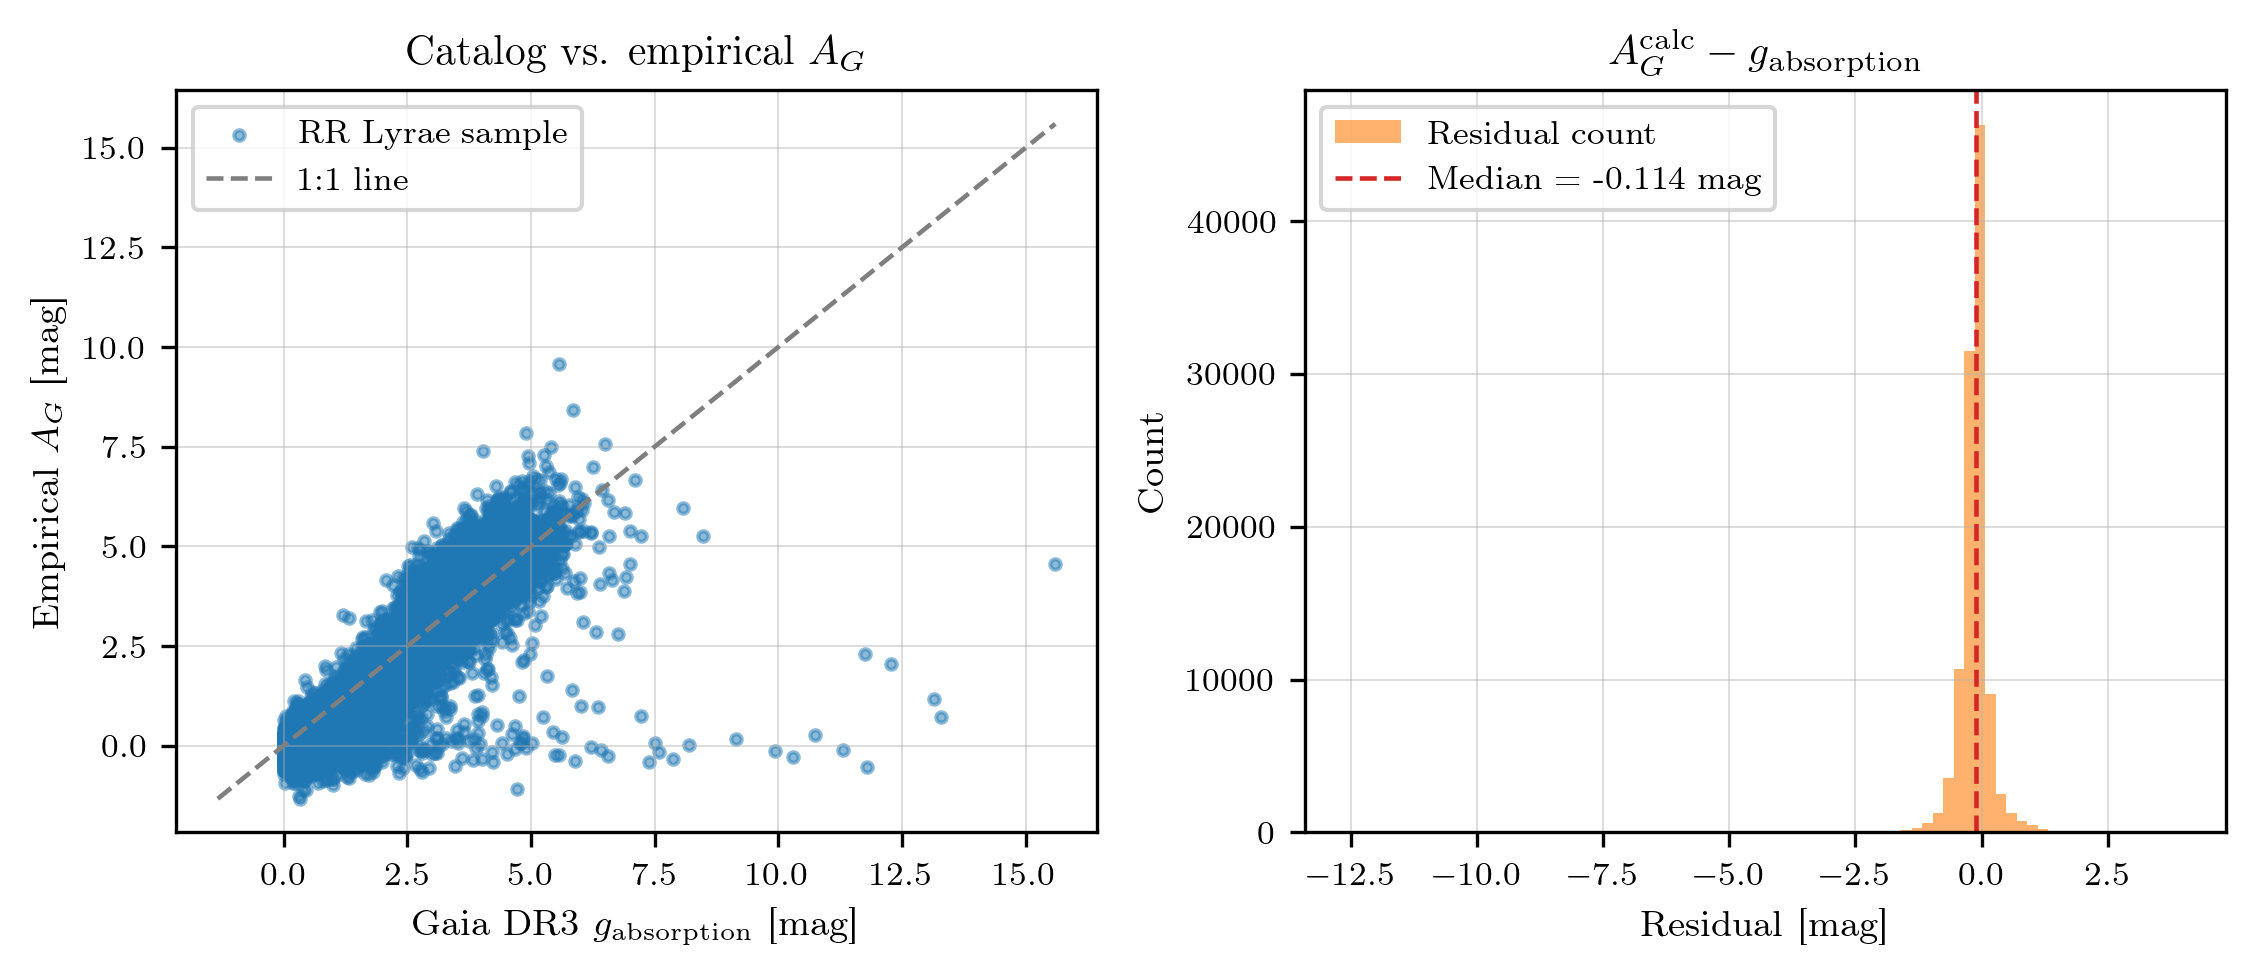

In [7]:
fig, axes = plot_empirical_vs_catalog_extinction_comparison(
    comparison.catalog,
    comparison.empirical,
    comparison.residuals,
    save=True,
)


In [8]:
from IPython.display import Markdown, display

all_row = comparison_summary[0]
rrab_row = comparison_summary[1]
rrc_row = comparison_summary[2]

discussion = rf"""
## Analysis and Discussion

This comparison should be interpreted as a test of consistency between two different extinction constructions, not as a demand for exact equality. Our empirical $A_G^{{calc}}$ is inferred from observed Gaia color minus a class-specific intrinsic RR Lyrae period-color relation, while Gaia DR3 `g_absorption` is tied to the extinction treatment used in the RR Lyrae pipeline and the underlying SFD dust-map framework (Clementini et al. 2023; Schlegel, Finkbeiner, & Davis 1998; Schlafly & Finkbeiner 2011).

In the current quality-filtered comparison sample, the residual $A_G^{{calc}} - g_{{absorption}}$ has median **{all_row['median_resid']:.4f} mag**, MAD-based scatter **{all_row['mad_sigma']:.4f} mag**, and RMS **{all_row['rms_resid']:.4f} mag** across **{all_row['N']}** matched stars. That is not star-by-star equality, but it is good enough to show that the empirical period-color calibration is recovering the same broad extinction scale as the Gaia RR Lyrae pipeline for the subset where both quantities are defined. The median offset is modest compared with the full residual width, so the main limitation is scatter rather than a catastrophic global bias.

The comparison is effectively **RRab-only**. The RRab row gives median residual **{rrab_row['median_resid']:.4f} mag** with RMS **{rrab_row['rms_resid']:.4f} mag**, while the RRc comparison row has **N = {rrc_row['N']}** because the current cached artifact contains no finite RRc `g_absorption` values even though empirical extinction quantities are still computed for RRc. That RRab-only behavior is consistent with the Gaia DR3 RR Lyrae release itself. Clementini et al. (2023) report that Gaia published an interstellar absorption estimate for 142 660 fundamental-mode RR Lyrae stars, derived from a relation involving the $G$-band amplitude, the $(G-G_{{\mathrm{{RP}}}})$ color, and the pulsation period. They do not present the same product as a general RRc extinction column.

After applying both the catalog sanity cut and the reddening-quality mask, the remaining largest empirical-minus-catalog differences should still be read cautiously. They can reflect imperfections in the class-specific intrinsic-color model, limits of a fixed $R_G = 2.0$ conversion, or differences between a star-by-star empirical estimate and a dust-map-based catalog value that effectively traces the line-of-sight dust column rather than the exact extinction to that pulsator. In other words, disagreement does not automatically imply one column is wrong; it often indicates that the two estimates are sensitive to different pieces of the extinction problem. The raw unfiltered scatter should therefore not be overinterpreted as a failure of the period-color relation by itself.

This notebook is intentionally scoped to RRab and RRc because the shared full-catalog cache and the saved period-color fit artifact are both defined only for the two single-mode subclasses. RRd is therefore excluded upstream rather than being carried through with undefined empirical-extinction fields.

### References

- Beaton, R. L., Bono, G., Braga, V. F., et al. (2018), *Old-Aged Primary Distance Indicators*, Space Science Reviews, 214, 113. https://doi.org/10.1007/s11214-018-0542-1
- Bono, G., Iannicola, G., Braga, V. F., et al. (2019), *On a New Method to Estimate the Distance, Reddening, and Metallicity of RR Lyrae Stars Using Optical/Near-infrared (B, V, I, J, H, K) Mean Magnitudes: $\omega$ Centauri as a First Test Case*, ApJ, 870, 115. https://doi.org/10.3847/1538-4357/aaf23f
- Clementini, G., Ripepi, V., Garofalo, A., et al. (2023), *Gaia Data Release 3: Specific processing and validation of all-sky RR Lyrae and Cepheid stars. The RR Lyrae sample*, A&A, 674, A18. https://doi.org/10.1051/0004-6361/202243964
- Schlegel, D. J., Finkbeiner, D. P., & Davis, M. (1998), *Maps of Dust Infrared Emission for Use in Estimation of Reddening and Cosmic Microwave Background Radiation Foregrounds*, ApJ, 500, 525. https://doi.org/10.1086/305772
- Schlafly, E. F., & Finkbeiner, D. P. (2011), *Measuring Reddening with Sloan Digital Sky Survey Stellar Spectra and Recalibrating SFD*, ApJ, 737, 103. https://doi.org/10.1088/0004-637X/737/2/103
"""

display(Markdown(discussion))


## Analysis and Discussion

This comparison should be interpreted as a test of consistency between two different extinction constructions, not as a demand for exact equality. Our empirical $A_G^{calc}$ is inferred from observed Gaia color minus a class-specific intrinsic RR Lyrae period-color relation, while Gaia DR3 `g_absorption` is tied to the extinction treatment used in the RR Lyrae pipeline and the underlying SFD dust-map framework (Clementini et al. 2023; Schlegel, Finkbeiner, & Davis 1998; Schlafly & Finkbeiner 2011).

In the current quality-filtered comparison sample, the residual $A_G^{calc} - g_{absorption}$ has median **-0.1140 mag**, MAD-based scatter **0.1638 mag**, and RMS **0.3690 mag** across **109325** matched stars. That is not star-by-star equality, but it is good enough to show that the empirical period-color calibration is recovering the same broad extinction scale as the Gaia RR Lyrae pipeline for the subset where both quantities are defined. The median offset is modest compared with the full residual width, so the main limitation is scatter rather than a catastrophic global bias.

The comparison is effectively **RRab-only**. The RRab row gives median residual **-0.1140 mag** with RMS **0.3690 mag**, while the RRc comparison row has **N = 0** because the current cached artifact contains no finite RRc `g_absorption` values even though empirical extinction quantities are still computed for RRc. That RRab-only behavior is consistent with the Gaia DR3 RR Lyrae release itself. Clementini et al. (2023) report that Gaia published an interstellar absorption estimate for 142 660 fundamental-mode RR Lyrae stars, derived from a relation involving the $G$-band amplitude, the $(G-G_{\mathrm{RP}})$ color, and the pulsation period. They do not present the same product as a general RRc extinction column.

After applying both the catalog sanity cut and the reddening-quality mask, the remaining largest empirical-minus-catalog differences should still be read cautiously. They can reflect imperfections in the class-specific intrinsic-color model, limits of a fixed $R_G = 2.0$ conversion, or differences between a star-by-star empirical estimate and a dust-map-based catalog value that effectively traces the line-of-sight dust column rather than the exact extinction to that pulsator. In other words, disagreement does not automatically imply one column is wrong; it often indicates that the two estimates are sensitive to different pieces of the extinction problem. The raw unfiltered scatter should therefore not be overinterpreted as a failure of the period-color relation by itself.

This notebook is intentionally scoped to RRab and RRc because the shared full-catalog cache and the saved period-color fit artifact are both defined only for the two single-mode subclasses. RRd is therefore excluded upstream rather than being carried through with undefined empirical-extinction fields.

### References

- Beaton, R. L., Bono, G., Braga, V. F., et al. (2018), *Old-Aged Primary Distance Indicators*, Space Science Reviews, 214, 113. https://doi.org/10.1007/s11214-018-0542-1
- Bono, G., Iannicola, G., Braga, V. F., et al. (2019), *On a New Method to Estimate the Distance, Reddening, and Metallicity of RR Lyrae Stars Using Optical/Near-infrared (B, V, I, J, H, K) Mean Magnitudes: $\omega$ Centauri as a First Test Case*, ApJ, 870, 115. https://doi.org/10.3847/1538-4357/aaf23f
- Clementini, G., Ripepi, V., Garofalo, A., et al. (2023), *Gaia Data Release 3: Specific processing and validation of all-sky RR Lyrae and Cepheid stars. The RR Lyrae sample*, A&A, 674, A18. https://doi.org/10.1051/0004-6361/202243964
- Schlegel, D. J., Finkbeiner, D. P., & Davis, M. (1998), *Maps of Dust Infrared Emission for Use in Estimation of Reddening and Cosmic Microwave Background Radiation Foregrounds*, ApJ, 500, 525. https://doi.org/10.1086/305772
- Schlafly, E. F., & Finkbeiner, D. P. (2011), *Measuring Reddening with Sloan Digital Sky Survey Stellar Spectra and Recalibrating SFD*, ApJ, 737, 103. https://doi.org/10.1088/0004-637X/737/2/103
